# HMM Output Analysis

This notebook visualizes the outputs of the `03_fit_shared_hmm.py` script.
We will load the artifacts and generate plots for:
1. Model selection (held-out log-likelihood vs. K)


3. Transition matrix for the best model
4. Regime prevalence (mean occupancy)
5. A graph of high-probability transitions

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Global plotting style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["svg.fonttype"] = "none"  # Editable text in SVG

In [9]:
# --- Configuration ---
ARTIFACTS_DIR = Path("../artifacts/chmm_8_full_dataset")
PROCESSED_DIR = Path("../data/processed")
REPO_ROOT = Path("..")

# --- Load Data ---
try:
    df_selection = pd.read_csv(ARTIFACTS_DIR / "model_selection.csv")
    with open(ARTIFACTS_DIR / "best_model.json") as f:
        params = json.load(f)
    
    best_K = params["K"]
    pT = np.array(params["pT"])
    pC = np.array(params["pC"])
    A = np.array(params["A"])
    
    df_decoded = pd.read_csv(ARTIFACTS_DIR / "decoded_sessions.csv")
    
    print(f"Successfully loaded artifacts for K={best_K}.")
    
except FileNotFoundError as e:
    print(f"Error loading artifacts: {e}")
    print("Please run the `make analysis` command to generate HMM results first.")

def _regime_order_and_labels(pT: np.ndarray, pC: np.ndarray) -> tuple[np.ndarray, list[str]]:
    """
    Determines a canonical ordering and labels for HMM regimes.
    The ordering is based on a hierarchical sort of the emission probabilities:
    1. Therapist valence (Neg, Neu, Pos)
    2. Client valence (Neg, Neu, Pos)
    3. A unique hash for tie-breaking.
    Labels are made unique by appending a number if duplicates exist.

    Args:
        pT: Therapist emission probability matrix (K x n_codes).
        pC: Client emission probability matrix (K x n_codes).

    Returns:
        A tuple containing:
        - order: An array of indices for the sorted regimes.
        - labels: A list of string labels for the sorted regimes.
    """
    K = pT.shape[0]
    
    # Determine dominant valence for each person in each regime
    therapist_valence = np.argmax(pT, axis=1)
    client_valence = np.argmax(pC, axis=1)
    
    # Create a sorting key
    # We use a large number to ensure separation of primary, secondary, etc. sort keys
    sort_key = (
        therapist_valence * 1_000_000 +
        client_valence * 1_000 +
        [(hash(str(pT[k])) + hash(str(pC[k]))) % 1000 for k in range(K)]
    )
    
    # Get the canonical order
    order = np.argsort(sort_key)
    
    # Create human-readable labels
    base_labels = []
    for k in order:
        t_val = ["Tneg", "Tneu", "Tpos"][therapist_valence[k]]
        c_val = ["Cneg", "Cneu", "Cpos"][client_valence[k]]
        base_labels.append(f"{t_val}-{c_val}")
        
    # Make labels unique by appending numbers
    counts = {}
    labels = []
    for label in base_labels:
        if base_labels.count(label) > 1:
            if label not in counts:
                counts[label] = 1
            else:
                counts[label] += 1
            labels.append(f"{label}-{counts[label]}")
        else:
            labels.append(label)
            
    return order, labels

Successfully loaded artifacts for K=8.


### 1. Model Selection Curve

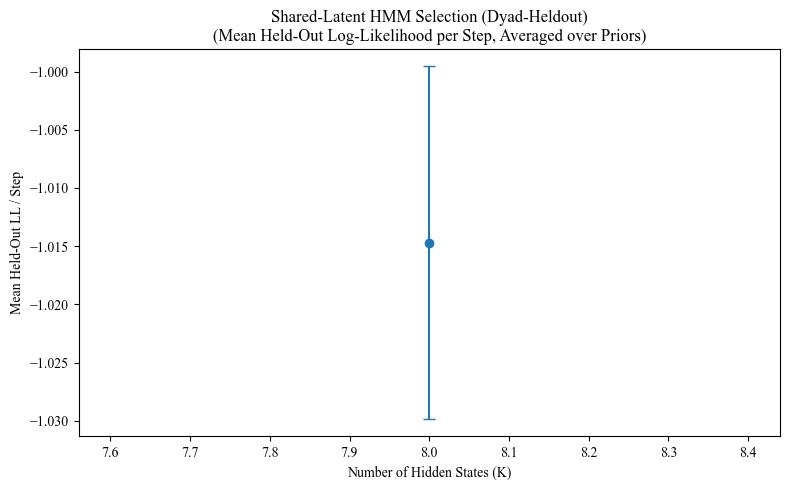

In [10]:
def plot_selection_curve(df: pd.DataFrame):
    """Plots the model selection curve (LL/step vs. K)."""
    byK = df.groupby("K")["test_ll_per_step"].agg(["mean", "sem"]).reset_index().sort_values("K")
    
    plt.figure(figsize=(8, 5))
    plt.errorbar(byK["K"], byK["mean"], yerr=byK["sem"], marker="o", capsize=4, linestyle='-')
    plt.title(
        "Shared-Latent HMM Selection (Dyad-Heldout)\n"
        "(Mean Held-Out Log-Likelihood per Step, Averaged over Priors)"
    )
    plt.xlabel("Number of Hidden States (K)")
    plt.ylabel("Mean Held-Out LL / Step")
    plt.tight_layout()
    plt.show()

if 'df_selection' in locals():
    plot_selection_curve(df_selection)

Stitched K coverage: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
     K  n_rows
0    2       5
1    3       5
2    4       5
3    5       5
4    6       5
5    7       5
6    8       5
7    9       5
8   10       5
9   11       5
10  12       5


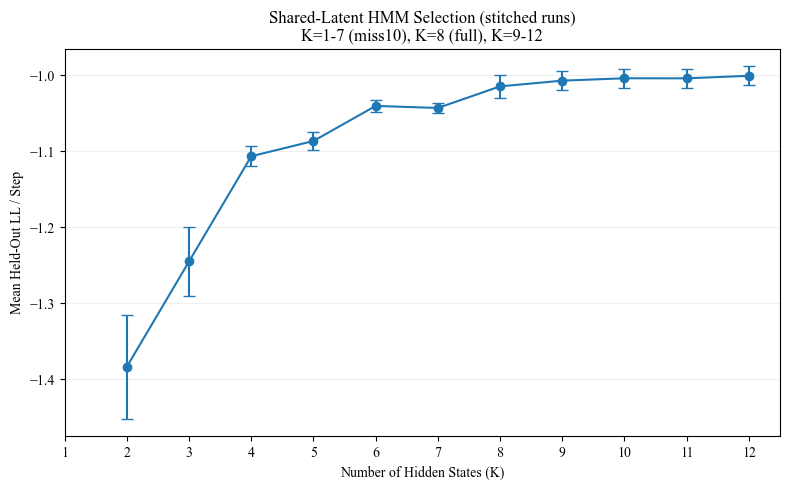

In [19]:
# Standalone stitched model-selection curve from split artifact runs (1-7, 8, 9-12)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base = Path("../artifacts")
sources = {
    "1to7": base / "chmm_1_to_8_miss10" / "model_selection.csv",
    "8full": base / "chmm_8_full_dataset" / "model_selection.csv",
    "9to12": base / "chmm_9_to_12" / "model_selection.csv",
}

for tag, fp in sources.items():
    if not fp.exists():
        raise FileNotFoundError(f"Missing {tag} file: {fp}")

def _pick_ll_column(df: pd.DataFrame) -> str:
    candidates = [
        "test_ll_per_step",
        "heldout_ll_per_step",
        "val_ll_per_step",
        "ll_per_step",
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(
        f"Could not find LL/step column in model_selection.csv. "
        f"Available columns: {list(df.columns)}"
    )

df_1 = pd.read_csv(sources["1to7"])
df_8 = pd.read_csv(sources["8full"])
df_9 = pd.read_csv(sources["9to12"])

if "K" not in df_1.columns or "K" not in df_8.columns or "K" not in df_9.columns:
    raise KeyError("Each model_selection.csv must contain a 'K' column.")

ll_col = _pick_ll_column(df_1)
if ll_col not in df_8.columns or ll_col not in df_9.columns:
    raise KeyError(
        f"Expected LL column '{ll_col}' in all files. "
        f"8-full columns: {list(df_8.columns)}; 9-12 columns: {list(df_9.columns)}"
    )

# Keep only the intended K windows from each run
part_1to7 = df_1[df_1["K"].between(1, 7)].copy()
part_8 = df_8[df_8["K"] == 8].copy()
part_9to12 = df_9[df_9["K"].between(9, 12)].copy()

df_stitched = pd.concat([part_1to7, part_8, part_9to12], ignore_index=True)
if df_stitched.empty:
    raise ValueError("No rows after stitching K ranges (1-7, 8, 9-12).")

# Aggregate within K (across priors/seeds if present)
byK = (
    df_stitched.groupby("K")[ll_col]
    .agg(["mean", "sem", "count"])
    .reset_index()
    .sort_values("K")
)

print("Stitched K coverage:", byK["K"].tolist())
print(byK[["K", "count"]].rename(columns={"count": "n_rows"}))

plt.figure(figsize=(8, 5))
plt.errorbar(
    byK["K"],
    byK["mean"],
    yerr=byK["sem"],
    marker="o",
    capsize=4,
    linestyle="-",
    color="tab:blue",
)
plt.title(
    "Shared-Latent HMM Selection (stitched runs)\n"
    "K=1-7 (miss10), K=8 (full), K=9-12"
)
plt.xlabel("Number of Hidden States (K)")
plt.ylabel("Mean Held-Out LL / Step")
plt.xticks(range(1, 13))
plt.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "selection_curve.svg")
plt.show()

### 2. Emission Profiles

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_1452/1223959212.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


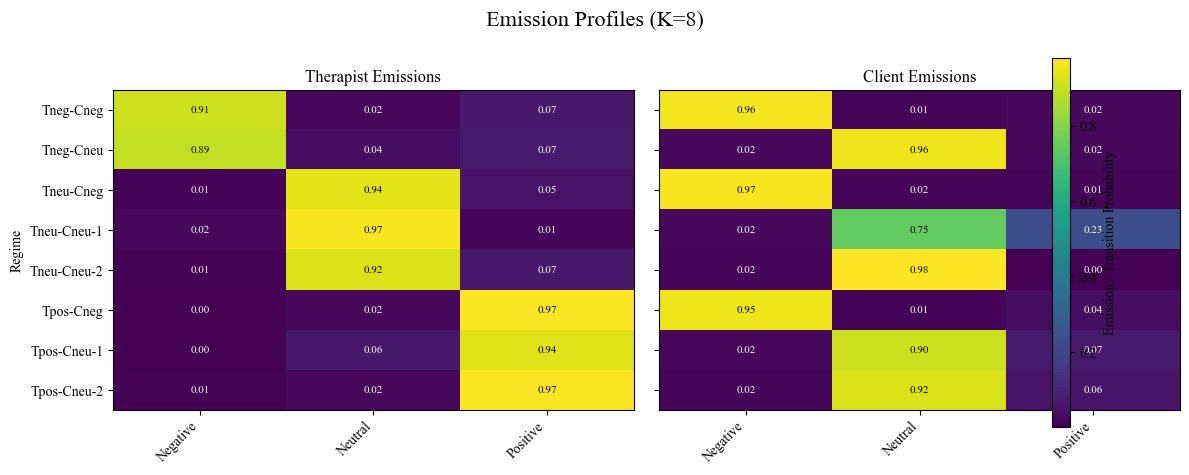

In [12]:
def plot_emissions(pT: np.ndarray, pC: np.ndarray, K: int, vmin=None, vmax=None, save_path=None):
    """Plots the emission probability matrices for therapist and client with a shared colorbar."""
    n_emit = pT.shape[1]

    # Get code names
    if n_emit == 3:
        code_names = ["Negative", "Neutral", "Positive"]
    else:
        try:
            spaff_codes = pd.read_csv(REPO_ROOT / "spaff_codes.csv")
            code_names = spaff_codes["code_name"].tolist()
        except FileNotFoundError:
            code_names = [f"Code {i}" for i in range(n_emit)]

    # Sort regimes for interpretability
    order, regime_labels = _regime_order_and_labels(pT, pC)
    pT_sorted = pT[order]
    pC_sorted = pC[order]

    # Shared color scale
    if vmin is None:
        vmin = min(pT.min(), pC.min())
    if vmax is None:
        vmax = max(pT.max(), pC.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, 0.6 * K)), sharey=True)

    # Therapist emissions
    im0 = axes[0].imshow(pT_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[0].set_title("Therapist Emissions")
    axes[0].set_ylabel("Regime")
    axes[0].set_yticks(np.arange(K))
    axes[0].set_yticklabels(regime_labels)
    axes[0].set_xticks(np.arange(len(code_names)))
    axes[0].set_xticklabels(code_names, rotation=45, ha="right")

    # Client emissions
    im1 = axes[1].imshow(pC_sorted, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    axes[1].set_title("Client Emissions")
    axes[1].set_xticks(np.arange(len(code_names)))
    axes[1].set_xticklabels(code_names, rotation=45, ha="right")

    # Add numeric annotations
    for i in range(K):
        for j in range(len(code_names)):
            axes[0].text(j, i, f"{pT_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pT_sorted[i, j] < 0.5 * vmax else "black")
            axes[1].text(j, i, f"{pC_sorted[i, j]:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if pC_sorted[i, j] < 0.5 * vmax else "black")

    # Place a single colorbar to the right of both subplots
    cbar = fig.colorbar(im1, ax=axes, orientation='vertical', fraction=0.025, pad=0.04, label="Emission / Transition Probability")
    fig.suptitle(f"Emission Profiles (K={K})", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save_path is not None:
        fig.savefig(save_path, format="svg")
    plt.show()

if 'pT' in locals():
    vmin = min(pT.min(), pC.min(), A.min()) if 'A' in locals() else min(pT.min(), pC.min())
    vmax = max(pT.max(), pC.max(), A.max()) if 'A' in locals() else max(pT.max(), pC.max())
    plot_emissions(pT, pC, best_K, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "emission_profiles.svg")

### 3. Transition Matrix

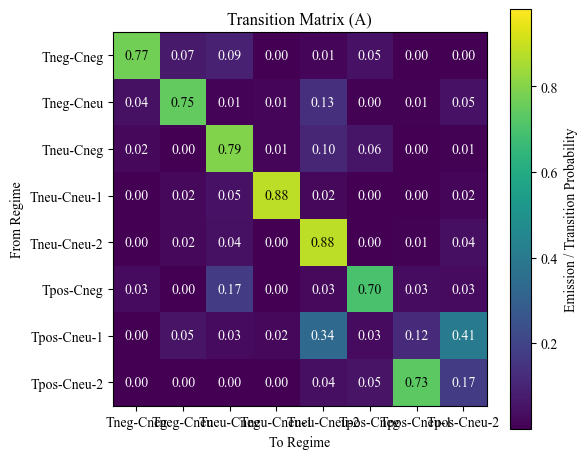

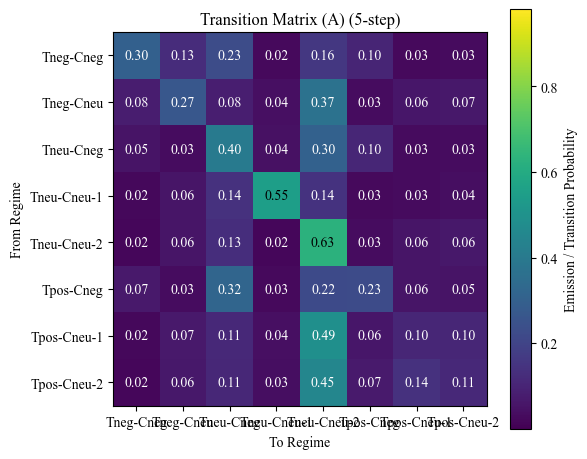

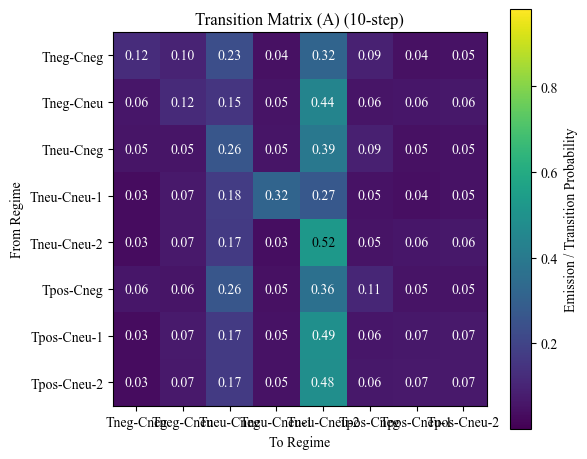

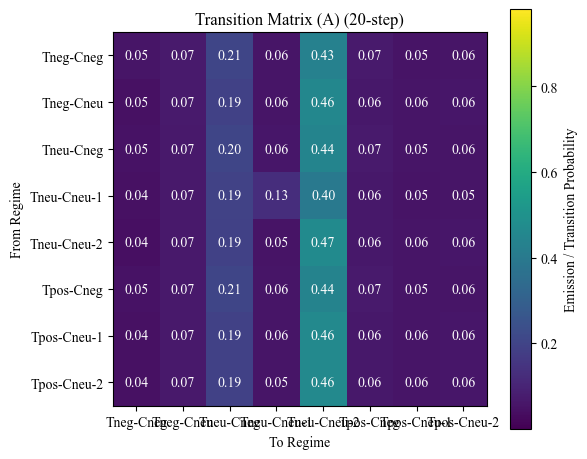

In [13]:
def plot_transition_matrix(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, vmin=None, vmax=None, save_path=None, title_suffix=""):
    """Plots the transition matrix, reordering states for interpretability, using a shared colorbar."""
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    if vmin is None:
        vmin = min(A.min(), pT.min(), pC.min())
    if vmax is None:
        vmax = max(A.max(), pT.max(), pC.max())

    plt.figure(figsize=(6, 5))
    im = plt.imshow(A_sorted, cmap="viridis", vmin=vmin, vmax=vmax)
    
    plt.title(f"Transition Matrix (A){title_suffix}")
    plt.xlabel("To Regime")
    plt.ylabel("From Regime")
    
    tick_labels = [label for label in regime_labels]
    plt.xticks(np.arange(K), tick_labels)
    plt.yticks(np.arange(K), tick_labels)

    # Annotate with probabilities
    for i in range(K):
        for j in range(K):
            plt.text(j, i, f"{A_sorted[i, j]:.2f}", ha="center", va="center",
                     color="white" if A_sorted[i, j] < 0.5 * vmax else "black")

    plt.colorbar(im, label="Emission / Transition Probability")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

def plot_multi_step_transition(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, steps: int, vmin=None, vmax=None, save_path=None):
    """Plot the k-step transition matrix (A^k) with the same regime order and colorbar."""
    Ak = np.linalg.matrix_power(A, steps)
    plot_transition_matrix(Ak, K, pT, pC, vmin=vmin, vmax=vmax, save_path=save_path, title_suffix=f" ({steps}-step)")

if 'A' in locals():
    vmin = min(pT.min(), pC.min(), A.min())
    vmax = max(pT.max(), pC.max(), A.max())
    plot_transition_matrix(A, best_K, pT, pC, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / "transition_matrix.svg")
    for kstep in [5, 10, 20]:
        plot_multi_step_transition(A, best_K, pT, pC, steps=kstep, vmin=vmin, vmax=vmax, save_path=ARTIFACTS_DIR / f"transition_matrix_{kstep}step.svg")


### 4. Regime Prevalence

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_1452/4095841733.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(occ_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)


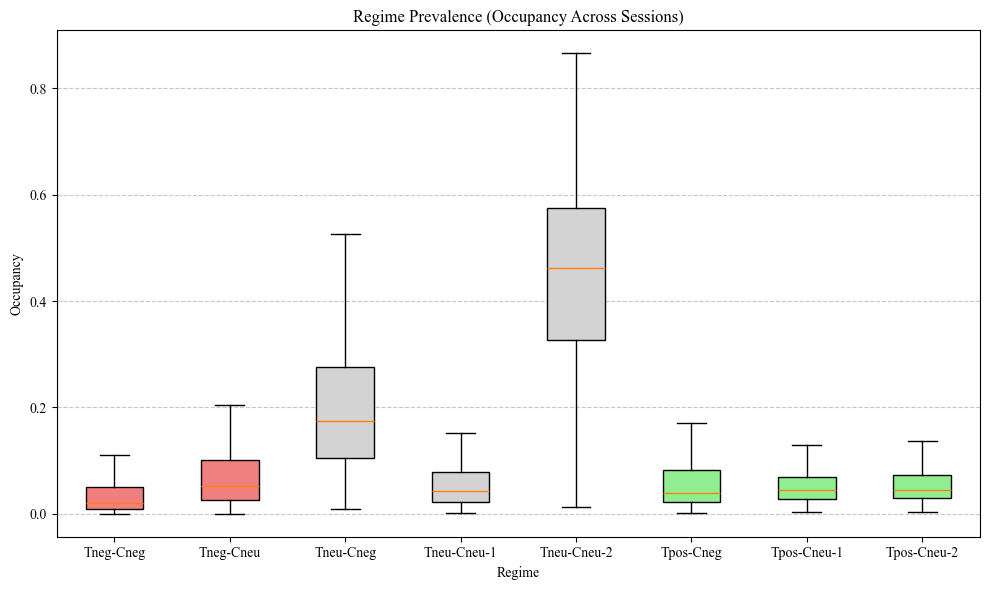

In [14]:
def plot_regime_prevalence(decoded_df: pd.DataFrame, K: int, pT: np.ndarray, pC: np.ndarray, save_path=None):
    """
    Box plot of occupancy across sessions, sorted to match the emissions heatmap
    and colored by therapist valence.
    """
    # Use the canonical ordering (same as emissions heatmap)
    order, regime_labels = _regime_order_and_labels(pT, pC)

    occ_cols = [f"occ_{k}" for k in range(K)]
    occ_data = decoded_df[occ_cols].to_numpy()

    # Reorder data to canonical order
    occ_data_sorted = occ_data[:, order]

    # Colors by therapist valence in the sorted order
    color_map = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
    colors = [color_map.get(label.split('-')[0], 'white') for label in regime_labels]

    plt.figure(figsize=(10, 6))
    box_plot = plt.boxplot(occ_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)

    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.ylabel("Occupancy")
    plt.xlabel("Regime")
    plt.title("Regime Prevalence (Occupancy Across Sessions)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if 'df_decoded' in locals():
    plot_regime_prevalence(df_decoded, best_K, pT, pC, save_path=ARTIFACTS_DIR / "regime_prevalence.svg")

### 5. Regime Transition Graph

Note: you may need to restart the kernel to use updated packages.


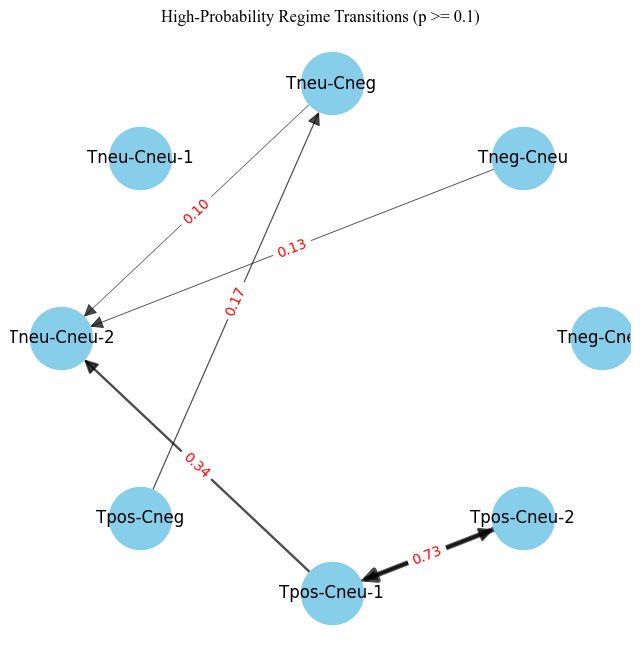

In [15]:
%pip install networkx

def plot_transition_graph(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray, threshold: float = 0.1, save_path=None):
    """Directed graph of high-probability transitions between regimes."""
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]
    tick_labels = [label for label in regime_labels]

    # Create a graph
    import networkx as nx
    G = nx.DiGraph()

    for i in range(K):
        G.add_node(i, label=tick_labels[i])

    for i in range(K):
        for j in range(K):
            p = A_sorted[i, j]
            if i != j and p >= threshold:
                G.add_edge(i, j, weight=p, label=f"{p:.2f}")

    plt.figure(figsize=(8, 8))
    pos = nx.circular_layout(G)
    
    node_labels = nx.get_node_attributes(G, 'label')
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="skyblue")
    nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12)
    
    edges = G.edges(data=True)
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=edges,
        width=[d['weight'] * 5 for _, _, d in edges],
        alpha=0.7,
        arrowsize=20,
        node_size=2000,
    )
    
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title("High-Probability Regime Transitions (p >= 0.1)")
    plt.axis("off")
    if save_path is not None:
        plt.savefig(save_path, format="svg")
    plt.show()

if 'A' in locals():
    plot_transition_graph(A, best_K, pT, pC, save_path=ARTIFACTS_DIR / "regime_transition_graph.svg")

### 6. Dwell Time and Exit Analysis

Here we analyze the properties of each regime, including how long the process is expected to stay in a regime (dwell time) and the uncertainty of where it goes next (exit entropy).

--- Regime Dynamics Analysis ---
Tneg-Cneg:
  - Self-transition prob (A[k,k]): 0.770
  - Expected Dwell Time (steps): 4.35
  - Exit Entropy (bits): 2.027
Tneg-Cneu:
  - Self-transition prob (A[k,k]): 0.746
  - Expected Dwell Time (steps): 3.94
  - Exit Entropy (bits): 1.994
Tneu-Cneg:
  - Self-transition prob (A[k,k]): 0.793
  - Expected Dwell Time (steps): 4.84
  - Exit Entropy (bits): 1.908
Tneu-Cneu-1:
  - Self-transition prob (A[k,k]): 0.884
  - Expected Dwell Time (steps): 8.64
  - Exit Entropy (bits): 2.179
Tneu-Cneu-2:
  - Self-transition prob (A[k,k]): 0.881
  - Expected Dwell Time (steps): 8.44
  - Exit Entropy (bits): 2.085
Tpos-Cneg:
  - Self-transition prob (A[k,k]): 0.699
  - Expected Dwell Time (steps): 3.32
  - Exit Entropy (bits): 1.924
Tpos-Cneu-1:
  - Self-transition prob (A[k,k]): 0.121
  - Expected Dwell Time (steps): 1.14
  - Exit Entropy (bits): 1.777
Tpos-Cneu-2:
  - Self-transition prob (A[k,k]): 0.171
  - Expected Dwell Time (steps): 1.21
  - Exit Entropy (bits

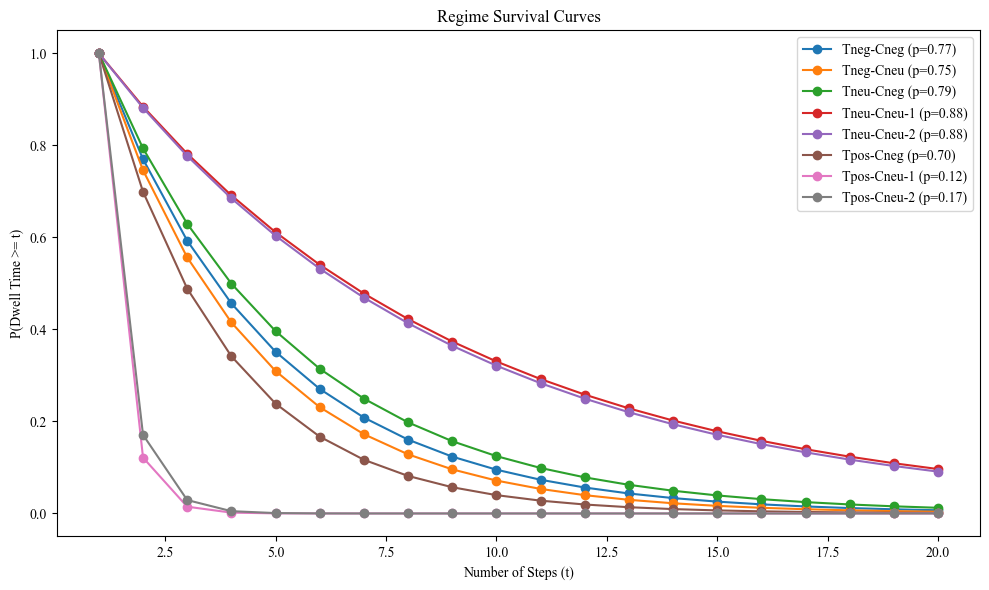

In [22]:
def analyze_regime_dynamics(A: np.ndarray, K: int, pT: np.ndarray, pC: np.ndarray):
    """
    Calculates and prints expected dwell times and exit entropies for each regime.
    Also plots survival curves for each regime.
    """
    order, regime_labels = _regime_order_and_labels(pT, pC)
    A_sorted = A[order][:, order]

    print("--- Regime Dynamics Analysis ---")
    
    # Dwell Times and Exit Entropies
    dwell_times = []
    exit_entropies = []
    
    for i in range(K):
        # Expected Dwell Time
        p_self = A_sorted[i, i]
        dwell_time = 1 / (1 - p_self) if p_self < 1 else float('inf')
        dwell_times.append(dwell_time)
        
        # Exit Probabilities & Entropy
        exit_probs = A_sorted[i, :].copy()
        exit_probs[i] = 0
        if np.sum(exit_probs) > 0:
            exit_probs /= np.sum(exit_probs)
            # Shannon entropy
            entropy = -np.sum([p * np.log2(p) for p in exit_probs if p > 0])
        else:
            entropy = 0
        exit_entropies.append(entropy)

        print(f"{regime_labels[i]}:")
        print(f"  - Self-transition prob (A[k,k]): {p_self:.3f}")
        print(f"  - Expected Dwell Time (steps): {dwell_time:.2f}")
        print(f"  - Exit Entropy (bits): {entropy:.3f}")

    # Survival Curves
    plt.figure(figsize=(10, 6))
    max_steps = 20
    steps = np.arange(1, max_steps + 1)
    
    for i in range(K):
        p_self = A_sorted[i, i]
        survival_prob = p_self ** (steps - 1)
        plt.plot(steps, survival_prob, marker='o', linestyle='-', label=f"{regime_labels[i]} (p={p_self:.2f})")

    plt.title("Regime Survival Curves")
    plt.xlabel("Number of Steps (t)")
    plt.ylabel("P(Dwell Time >= t)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "regime_survival_curves.svg", format="svg")
    plt.show()


if 'A' in locals():
    analyze_regime_dynamics(A, best_K, pT, pC)

### 7. Dwell Time Distribution Analysis

Next, we'll compute the empirical dwell time distributions from the Viterbi paths of all sessions. This allows us to test whether the observed dwell times differ significantly across regimes using ANOVA and Kruskal-Wallis tests. We also visualize the distributions with a boxplot.


--- Dwell Time Distribution Analysis ---
One-way ANOVA on dwell times across regimes: F=2121.395, p=0
Kruskal-Wallis test on dwell times across regimes: H=48866.870, p=0


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_1452/1447083432.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(dwell_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)


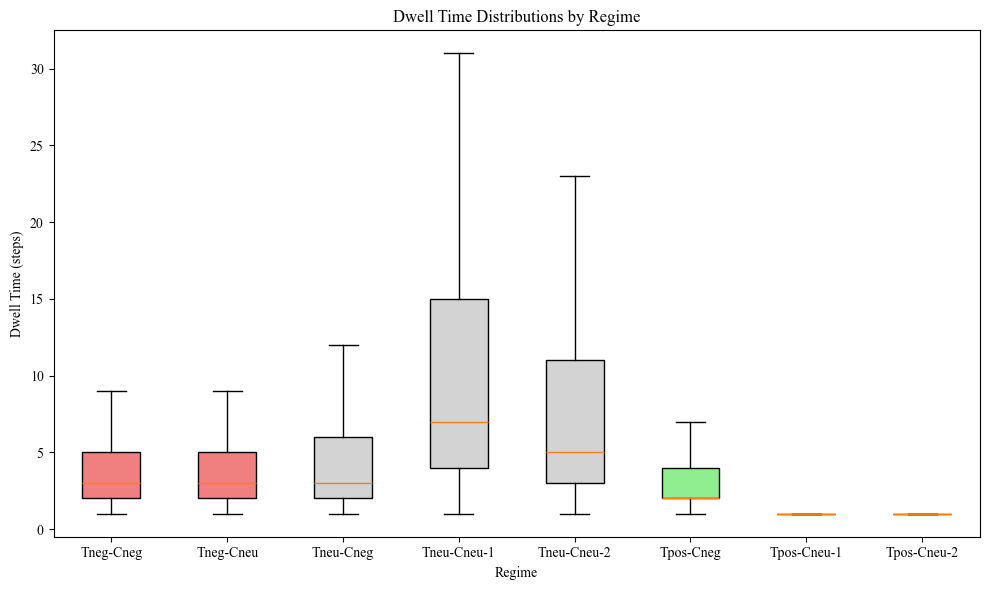

In [21]:
from scipy.stats import f_oneway, kruskal

def get_dwell_times_from_paths(decoded_df: pd.DataFrame, K: int) -> dict[int, list[int]]:
    """
    Computes the empirical dwell times for each regime from the Viterbi paths.
    """
    dwells_by_regime = {k: [] for k in range(K)}
    
    for _, row in decoded_df.iterrows():
        path_file = ARTIFACTS_DIR / row["path_file"]
        if not path_file.exists():
            continue
        
        path = np.load(path_file)
        if len(path) == 0:
            continue
            
        # Find where the regime changes
        change_points = np.where(path[:-1] != path[1:])[0]
        
        # Segment lengths are the differences between change points
        segment_lengths = np.diff(np.concatenate(([-1], change_points, [len(path) - 1])))
        
        # The regime for each segment is the value at the start of the segment
        segment_regimes = path[np.concatenate(([0], change_points + 1))]
        
        for regime, length in zip(segment_regimes, segment_lengths):
            dwells_by_regime[regime].append(length)
            
    return dwells_by_regime

def analyze_dwell_time_distributions(dwells_by_regime: dict[int, list[int]], K: int, pT: np.ndarray, pC: np.ndarray):
    """
    Performs ANOVA and Kruskal-Wallis tests on dwell time distributions and plots them.
    Colors the boxplots by therapist valence.
    """
    order, regime_labels = _regime_order_and_labels(pT, pC)
    
    # Reorder the dwell time data according to the canonical regime order
    dwell_data_sorted = [dwells_by_regime[k] for k in order]
    
    print("\n--- Dwell Time Distribution Analysis ---")
    
    # Statistical Tests
    if all(len(d) > 1 for d in dwell_data_sorted):
        # One-way ANOVA
        f_stat, p_anova = f_oneway(*dwell_data_sorted)
        print(f"One-way ANOVA on dwell times across regimes: F={f_stat:.3f}, p={p_anova:.3g}")

        # Kruskal-Wallis H-test (non-parametric alternative)
        h_stat, p_kruskal = kruskal(*dwell_data_sorted)
        print(f"Kruskal-Wallis test on dwell times across regimes: H={h_stat:.3f}, p={p_kruskal:.3g}")
    else:
        print("Skipping statistical tests: not enough data in one or more regimes.")

    # Define colors based on therapist valence
    color_map = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
    colors = [color_map.get(label.split('-')[0], 'white') for label in regime_labels]

    # Boxplot of Dwell Time Distributions
    plt.figure(figsize=(10, 6))
    box_plot = plt.boxplot(dwell_data_sorted, labels=regime_labels, showfliers=False, patch_artist=True)
    
    # Set colors for each box
    for patch, color in zip(box_plot['boxes'], colors):
        patch.set_facecolor(color)

    plt.title("Dwell Time Distributions by Regime")
    plt.xlabel("Regime")
    plt.ylabel("Dwell Time (steps)")
    plt.tight_layout()
    plt.savefig(ARTIFACTS_DIR / "dwell_time_distributions.svg", format="svg")
    plt.show()

if 'df_decoded' in locals():
    dwells = get_dwell_times_from_paths(df_decoded, best_K)
    analyze_dwell_time_distributions(dwells, best_K, pT, pC)